In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene'

In [8]:
import sys, os

print(os.getpid())

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

def add_path(p: str):
    if p not in sys.path:
        sys.path.append(p)

add_path(os.environ['LP_ROOT'])
add_path(os.environ['PROJECT'])

import project

import torch
assert torch.cuda.is_available()

2515549


# Gather examples

In [9]:
from pathlib import Path
#data_root = Path(os.environ['LP_ROOT'] / 'data' / 'COPDGene'
data_root = Path(os.environ['PRIVATE']) / 'data' / 'COPDGene'
data_root.is_dir()
data_root

PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene')

In [10]:
subject_file = data_root / 'sample1000_2025-07-22.csv'
subject_list = project.fileio.load_subject_list(subject_file, key='sid', sep='\t')
len(subject_list)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-22.csv


1000

In [11]:
data_config = {
    'name': 'COPDGene',
    'root': str(data_root),
    'subjects': subject_list,
    'state_pairs': [('EXP', 'INSP')]
}

In [12]:
%autoreload
examples = project.get_examples(data_config)

Gathering examples...
1000 total


# View source images

In [13]:
import numpy as np

ex = examples[0]

def get_oriented_spacing(affine: np.ndarray):
    return tuple(float(d) for d in affine[:3,:3] @ np.ones(3))

src0 = project.fileio.load_nibabel(ex.paths['init_state']['source_image'])
src1 = project.fileio.load_nibabel(ex.paths['curr_state']['source_image'])

src0_spacing = get_oriented_spacing(src0.affine)
src1_spacing = get_oriented_spacing(src1.affine)

print(src0_spacing)
print(src1_spacing)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz
(-0.71875, 0.71875, 0.5)
(-0.71875, 0.71875, 0.7000007629394531)


In [14]:
import project.visual.matplotlib as mpl_viz
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

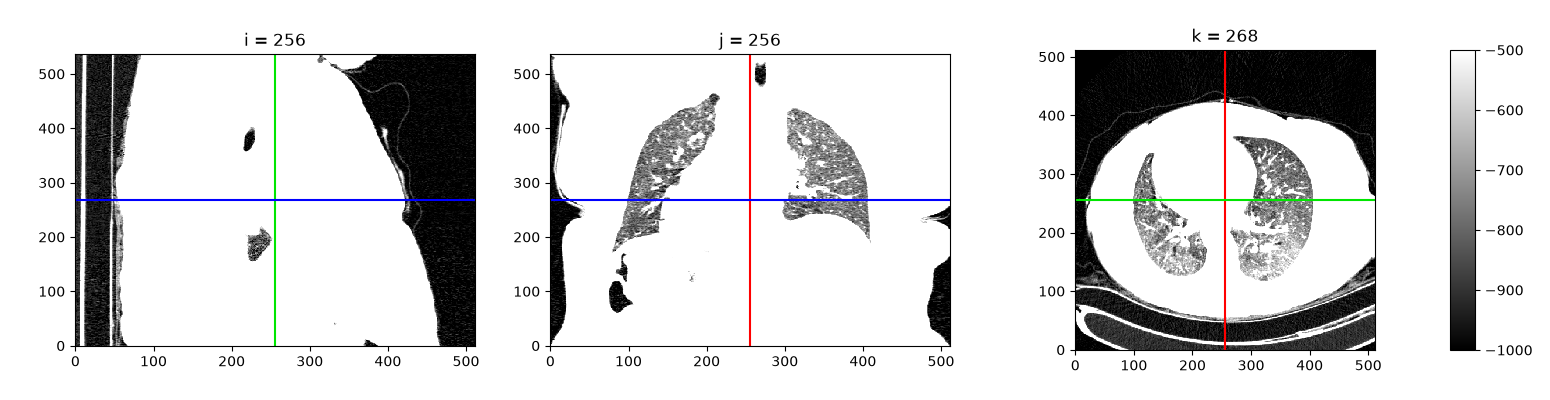

In [15]:
mpl_viz.SliceViewer(src0.get_fdata(), vox_spacing=src0_spacing, ax_height=3, ax_width=4, **img_kws)

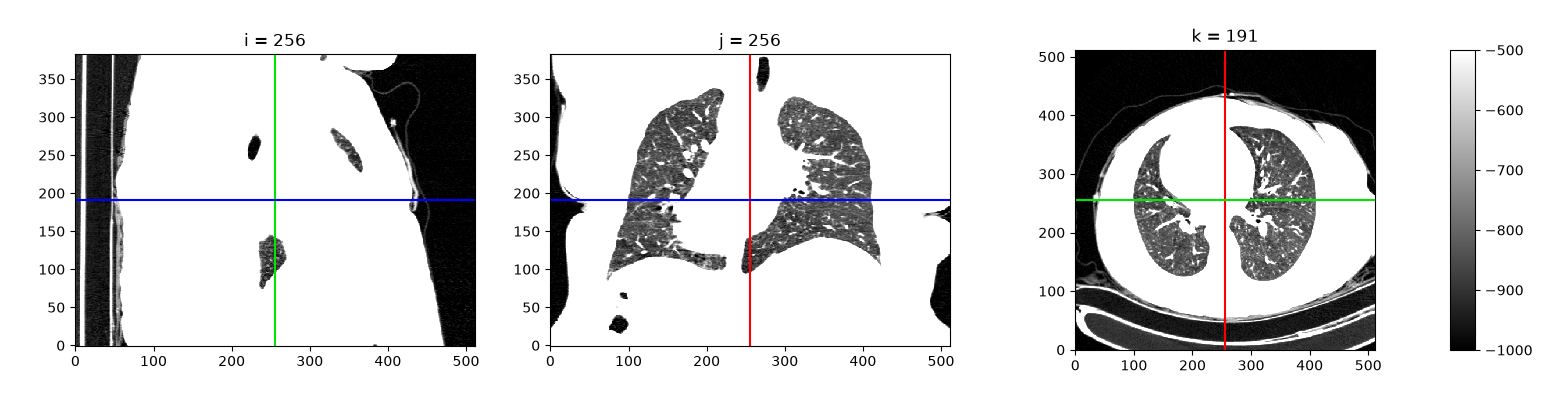

In [16]:
mpl_viz.SliceViewer(src1.get_fdata(), vox_spacing=src1_spacing, ax_height=3, ax_width=4, **img_kws)

# Preprocessing tests

In [17]:
data_config = {
    'name': 'COPDGene',
    'root': str(data_root),
    'subjects': subject_list,
    'state_pairs': [('EXP', 'INSP')],
    'variant': 'TEST',
    'pipeline_tags': {
        'image_segmentation':  'v0',
        'material_properties': 'v3',
        'mesh_generation':     'v2',
        'forward_simulation':  'linear'
    }
}
project.utils.pprint(data_config, max_depth=3)

dict(len=6)
├── 'name':          'COPDGene'
├── 'root':          '/restricted/projectnb/batmanlab/mragoza/data/COPDGene'
├── 'subjects':      list(len=1000)
|   ├── 0: '16514P'
|   ├── 1: '20748Q'
|   ├── 2: '11007Z'
|   ├── 3: '14771Z'
|   ├── 4: '13651K'
|   ├── 5: '15900P'
|   ├── 6: '15312Y'
|   ├── 7: '21042H'
|   ├── 8: '21877G'
|   ├── 9: '10127E'
|   └── <990 more items>
├── 'state_pairs':   list(len=1)
|   └── 0: tuple(len=2)
|       ├── 0: 'EXP'
|       └── 1: 'INSP'
├── 'variant':       'TEST'
└── 'pipeline_tags': dict(len=4)
    ├── 'image_segmentation':  'v0'
    ├── 'material_properties': 'v3'
    ├── 'mesh_generation':     'v2'
    └── 'forward_simulation':  'linear'


In [18]:
def estimate_circumradius(num_voxels, voxel_volume=1.0):
    total_volume = num_voxels * voxel_volume
    return 1.25 * total_volume ** (1 / 3)

[round(estimate_circumradius(n**3), 4) for n in [1, 2, 3, 4, 5]]

[1.25, 2.5, 3.75, 5.0, 6.25]

In [19]:
nnu_weights_dir = '/restricted/projectnb/batmanlab/haozhe/Lung_Mesh_Segment/data/nnUNetv2/nnUNet_results'
ugi_weights_dir = '/projectnb/batmanlab/mragoza/lung-project/network_weights'

lung_roi_subset = [
    'lung_upper_lobe_right',
    'lung_middle_lobe_right',
    'lung_lower_lobe_right',
    'lung_upper_lobe_left', 
    'lung_lower_lobe_left'
]

proc_config = {
    'image_resampling': {
        'spacing': (1.0, 1.0, 1.0),
        'interpolator': 'linear',
        'default_value': -1000.
    },
    'image_segmentation': {
        'tasks': [
            {
                'method': 'TotalSegmentator',
                'kwargs': {'task': 'total', 'roi_subset': lung_roi_subset}
            },
            {
                'method': 'TotalSegmentator',
                'kwargs': {'task': 'lung_vessels'}
            },
            {
                'method': 'VisionFeature',
                'kwargs': {'model': 'vista3d', 'results_dir': nnu_weights_dir}
            },
            {
                'method': 'HU_threshold',
                'kwargs': {
                    'thresholds': {
                        'lt-950': {'type': 'absolute', 'operator': '<', 'value': -950},
                        'lt-910': {'type': 'absolute', 'operator': '<', 'value': -910},
                        'lt-850': {'type': 'absolute', 'operator': '<', 'value': -850},
                        'gt-500': {'type': 'absolute', 'operator': '>', 'value': -500},
                        'gt-200': {'type': 'absolute', 'operator': '>', 'value': -200},
                    }
                }
            }
        ]
    },
    'image_registration': {
        'method': 'unigradicon',
        'kwargs': {
            'model': 'gradiconlung',
            'similarity': 'lncc2',
            'sigma': 1,
            'iterations': 50,
            'loss_function_masking': True,
            'intensity_conservation': True,
            'weights_root': ugi_weights_dir
        }
    },
    'anatomical_regions': {
        'roi_order': lung_roi_subset,
        'filter_kws': {'min_voxels': 30, 'keep_largest': True}
    },
    'material_properties': {
        'density': {
            #'base_value': 1000., 'terms': {'image': 1.0}, 'range': [1., 2000.]
            'base_value': 350., # v1,v2
        },
        'youngs_modulus': {
            'base_value': 2000.,
            'terms': {
                'lung_arteries': +3000., 
                'lung_veins':    +3000.,
                'lung_airways':  +6000.,
                
                'ggo':           +2000.,
                'consolidation': +4000.,
                'nodule':        +8000.,

                'lt-850': -1000.,
                'lt-910':  -500.,
                'lt-950':  -250.,

                #'lung_upper_lobe_right': +2000.,
                #'lung_lower_lobe_right': -1000.,

                #'lung_upper_lobe_left': +2000.,
                #'lung_lower_lobe_left': -1000,
            },
            'sigma': 3.75,
            'range': [1., 20000.]
        },
        'poisson_ratio': {'base_value': 0.42}
    },
    'mesh_generation': {
        'use_search': True,
        'pygalmesh_kws': {
            'max_cell_circumradius': 3.75,
            'max_facet_distance': 1.0,
            'lloyd': True,
            'odt': True
        }
    },
    'field_interpolation': {
        'displacement_key': 'u_reg'
    },
    'forward_simulation': {
        'pde_solver': {
            'type': 'warp',
            'material_type': 'linear',
            'g_vector': [0., -9.81, 0.],
            'scalar_degree': 1,
            'vector_degree': 1,
            'newton_steps': 100,
            'newton_tries': 32,
            'newton_alpha': 1.0,
            'newton_beta': 0.5,
            'newton_rtol': 1e-4,
            'cg_maxiter': 1000,
            'cg_rtol': 1e-5,
            'verbose': True
        },
        'boundary_condition': {'type': 'mesh_key', 'value': 'u_reg'},
        'output_key': 'u_fwd'
    }
}
print('ready')

ready


In [25]:
%autoreload
#config = project.fileio.load_config('../../config/copdgene.yaml')
config = {'dataset': data_config, 'preprocessing': proc_config}
examples = project.get_examples(config['dataset'])
project.run_preprocess(examples[:1], config['preprocessing'])

Gathering examples...
1000 total
[Example 0/1] Preprocessing subject: 16514P
INFO: Skipping stage resample_image_spacing
INFO: Skipping stage create_segmentation_masks
INFO: Skipping stage resample_image_spacing
INFO: Skipping stage create_segmentation_masks
INFO: Skipping stage estimate_displacement_field
INFO: Skipping stage label_anatomical_regions
INFO: Skipping stage assign_material_properties
INFO: Running stage generate_tetrahedral_mesh
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz
Generating tetrahedral mesh
Start mesh resolution search
Target max_cell_circumradius: 3.75
Saving mask as INR file
Generating mesh from INR file
radius = 3.7500  n_verts = 36224  n_cells = 179339
Post-processing generated mesh


<meshio mesh object>
  Number of points: 36222
  Number of cells:
    tetra: 179339
  Point data: medit:ref
  Cell data: medit:ref, label
Saving /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_anat_v2.xdmf
INFO: Running stage interpolate_mesh_fields
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_anat_v2.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_corr_INSP.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/165

Saving /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v2_v3_int.xdmf
INFO: Running stage simulate_displacement_field
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v2_v3_int.xdmf
Saving /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v2_v3_int_linear.xdmf
[Example 1/1] Done


In [26]:
!nvidia-smi

Wed Sep 16 10:50:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.57.04              KMD Version: 610.57.04     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    On  |   00000000:01:00.0 Off |                    0 |
| 30%   40C    P2             65W /  300W |     660MiB /  46068MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Interactive visualization

In [27]:
ex = project.get_examples(data_config)[0]

Gathering examples...
1000 total


In [28]:
img0 = project.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])

img0_spacing = get_oriented_spacing(img0.affine)
img1_spacing = get_oriented_spacing(img1.affine)

print(img0_spacing)
print(img1_spacing)

anat = project.fileio.load_nibabel(ex.paths['anatomical_map'])
mat = project.fileio.load_nibabel(ex.paths['material_map'])

emph = project.fileio.load_nibabel(ex.paths['init_state']['segment_dir'] / 'lt-850.nii.gz')

m = anat.get_fdata() > 0
print(m.sum(), 'voxels')

E = project.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

mesh = project.fileio.load_meshio(ex.paths['target_mesh'])
mesh

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz
(-1.0, 1.0, 1.0)
(-1.0, 1.0, 1.0)
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3_label.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0/lt-850.nii.gz
2144299 voxels
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3/poisson_ratio.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields

<meshio mesh object>
  Number of points: 36222
  Number of cells:
    tetra: 179339
  Point data: medit:ref, image, u_reg, E, nu, rho, u_fwd
  Cell data: medit:ref, label, image, u_reg, E, nu, rho, u_fwd

In [29]:
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

anat_kws = dict(cmap=mpl_viz.get_label_cmap(5, include_bg=True), vmin=0, vmax=5)
mask_kws = dict(cmap='binary', vmin=0, vmax=1)

rho_kws = dict(cmap='jet', vmin=0, vmax=1000)
nu_kws = dict(cmap='jet', vmin=0, vmax=0.5)
E_kws = dict(cmap='jet', vmin=0, vmax=1e4)

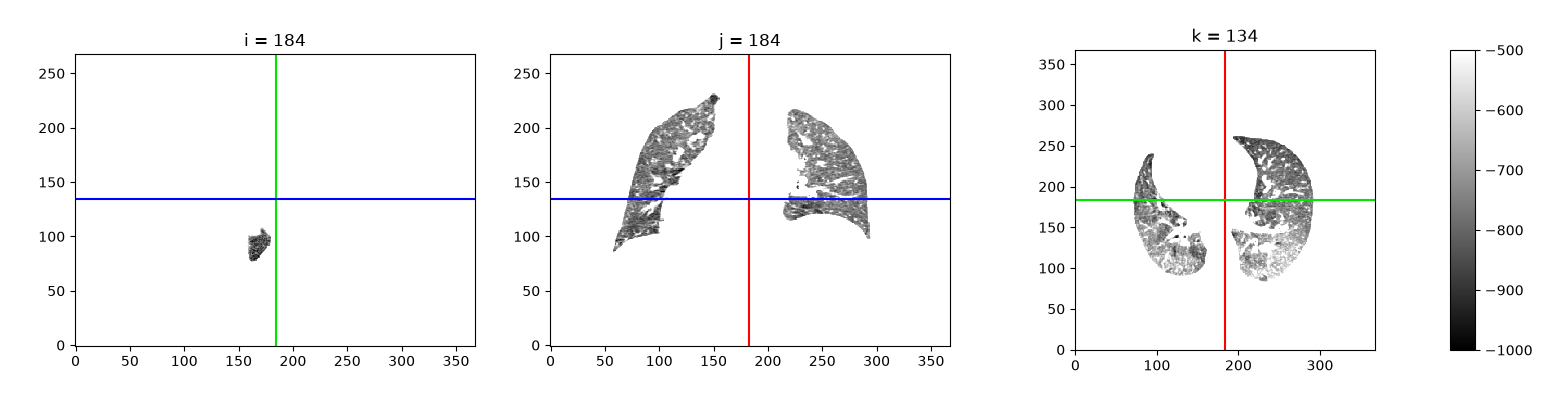

In [30]:
mpl_viz.SliceViewer(img0.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **img_kws)

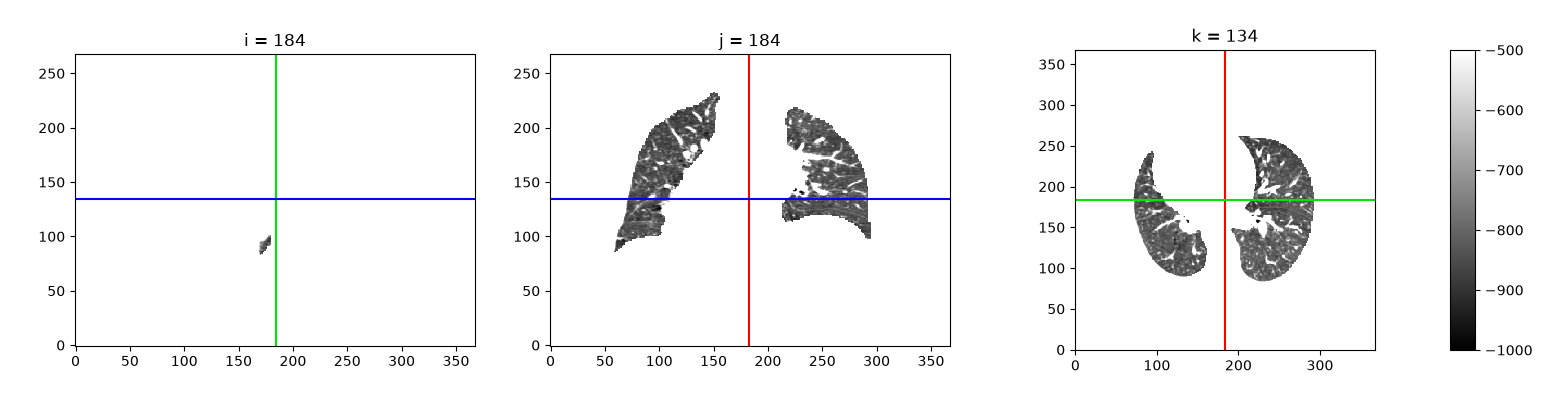

In [31]:
mpl_viz.SliceViewer(img1.get_fdata() * m, vox_spacing=img1_spacing, ax_height=3, ax_width=4, **img_kws)

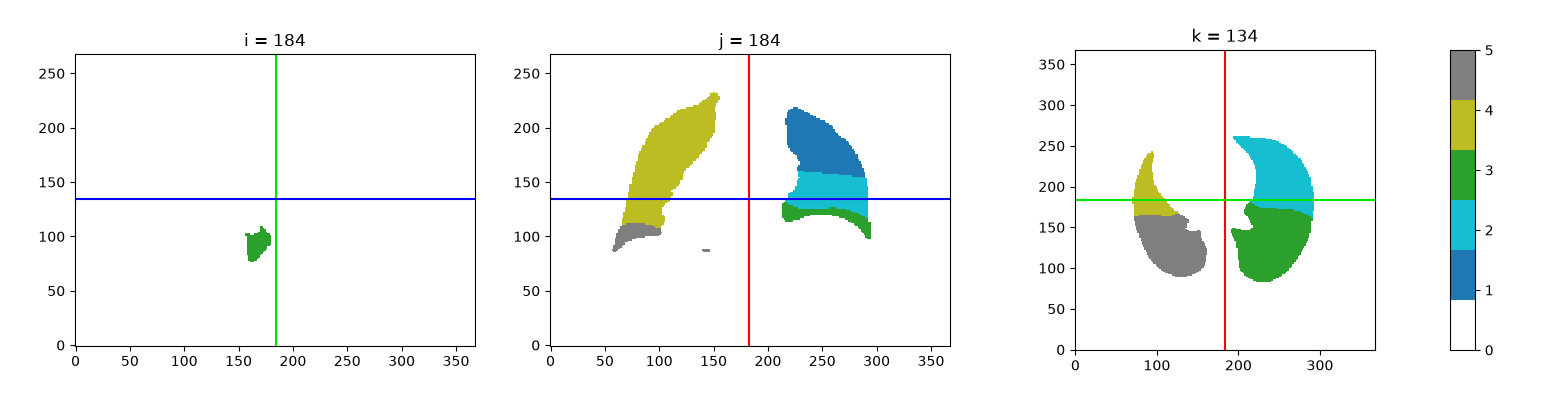

In [32]:
mpl_viz.SliceViewer(anat.get_fdata(), vox_spacing=img0_spacing, ax_height=3, ax_width=4, **anat_kws)

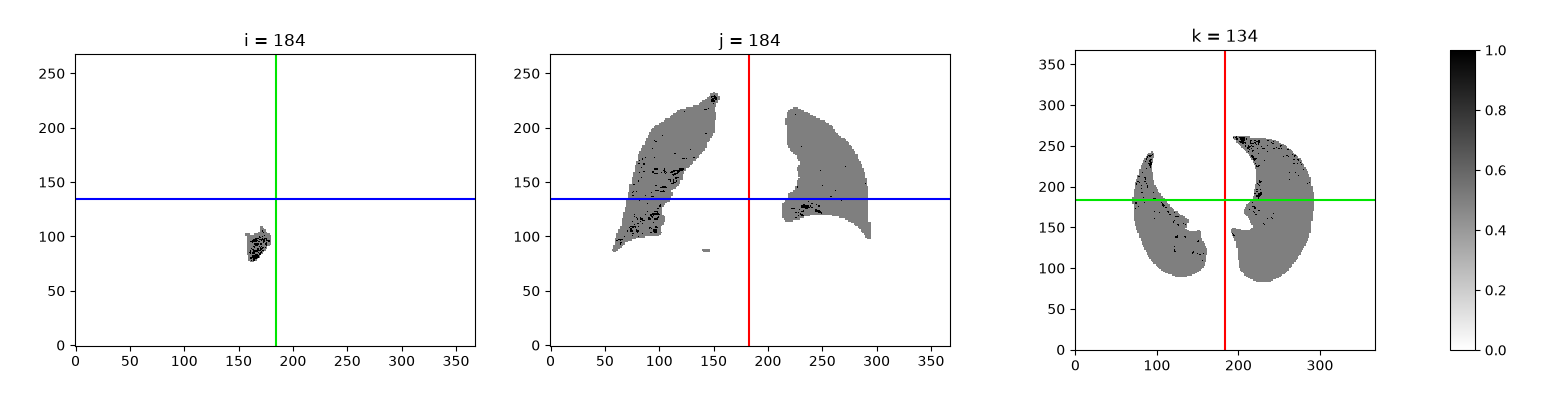

In [33]:
mpl_viz.SliceViewer((emph.get_fdata() + 1) / 2 * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **mask_kws)

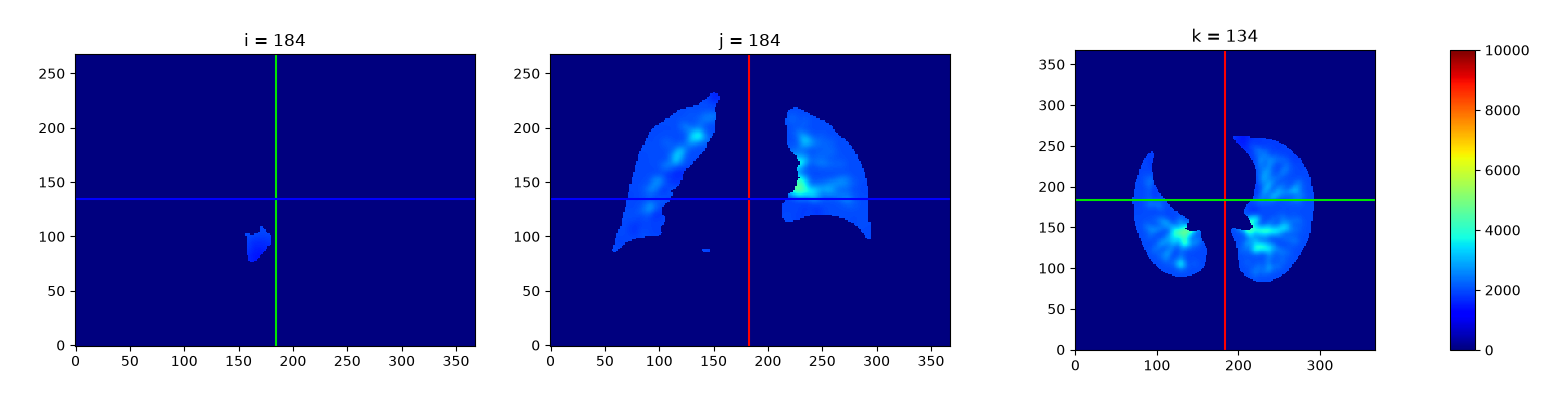

In [34]:
mpl_viz.SliceViewer(E.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **E_kws)

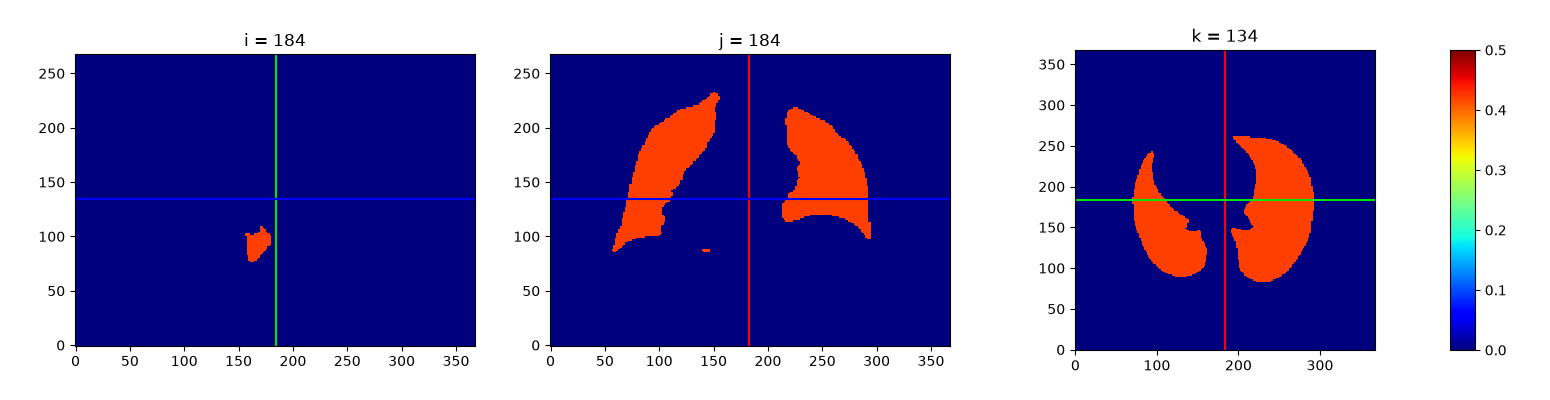

In [35]:
mpl_viz.SliceViewer(nu.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **nu_kws)

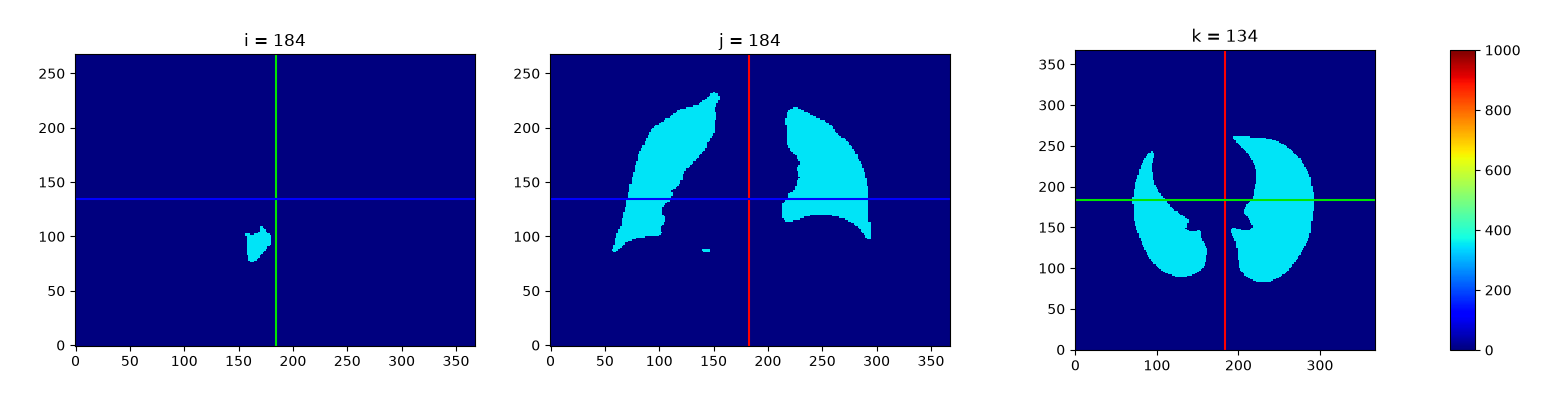

In [36]:
mpl_viz.SliceViewer(rho.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **rho_kws)

2026-09-16 10:50:27.227 ( 723.765s) [    1512B10DE200]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


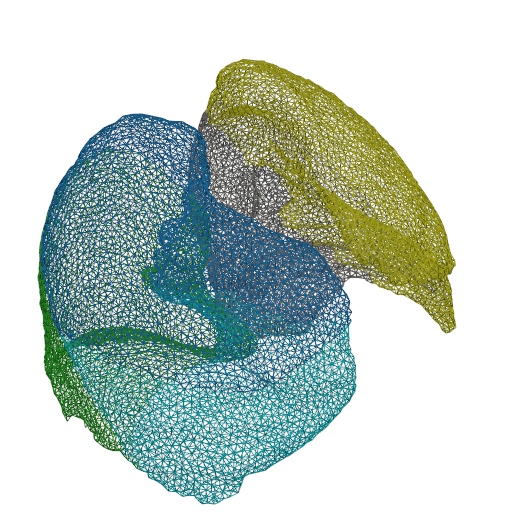

In [37]:
def show_mesh(mesh, window_size=(512,512), camera_zoom=4/3, **kwargs):
    import pyvista as pv
    p = pv.Plotter(window_size=window_size)
    p.add_mesh(pv.wrap(mesh), **kwargs)
    p.camera.zoom(camera_zoom)
    p.show(jupyter_backend='static')

show_mesh(
    mesh,
    style='wireframe',
    scalars='label',
    cmap=mpl_viz.get_label_cmap(5, include_bg=False),
    clim=(1, 5),
    show_scalar_bar=False
)

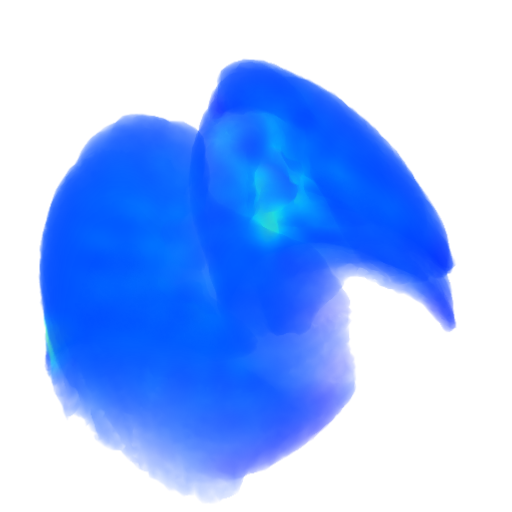

In [38]:
def show_scalar(mesh, window_size=(512,512), camera_zoom=4/3, **kwargs):
    import pyvista as pv
    p = pv.Plotter(window_size=window_size)
    p.add_volume(pv.wrap(mesh), **kwargs)
    p.camera.zoom(camera_zoom)
    p.show(jupyter_backend='static')

show_scalar(
    mesh,
    scalars='E',
    cmap='jet',
    clim=(0, 1e4),
    opacity=0.05,
    show_scalar_bar=False
)

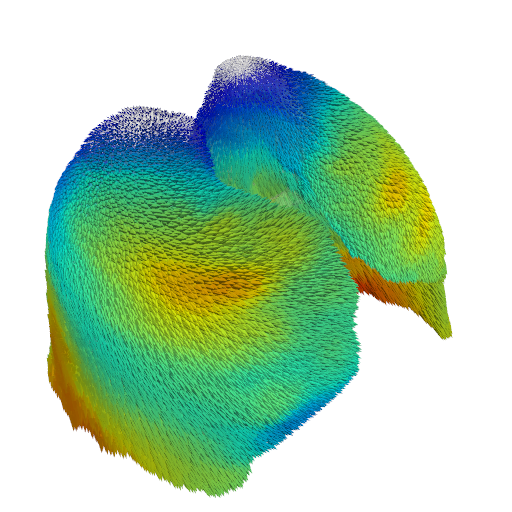

In [39]:
def show_vector(mesh, key, window_size=(512,512), camera_zoom=4/3):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=window_size)
    p.add_mesh(m, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, cmap='jet', show_scalar_bar=False)
    p.camera.zoom(camera_zoom)
    p.show(jupyter_backend='static')

    surf = pv.wrap(mesh).extract_surface(algorithm='geometry')

show_vector(mesh, key='u_reg')

# Optimization

In [40]:
opt_config = {
    'parameters': {
        'E': {'mode': 'log10', 'mean': 3.301, 'std': 1.0}
    },
    'physics_adapter': {},
    'pde_solver': {
        'type': 'warp',
        'material_type': 'linear',
        'g_vector': [0., -9.81, 0.],
        'relative_loss': True,
        'tv_reg_weight': 1e-4,
        'newton_steps': 100,
        'newton_tries': 32,
        'newton_alpha': 1.0,
        'newton_beta': 0.5,
        'newton_rtol': 1e-4,
        'cg_maxiter': 1000,
        'cg_rtol': 1e-5,
        'scalar_degree': 1,
        'vector_degree': 1,
        'verbose': True        
    },
    'boundary_condition': {
        'type': 'mesh_key',
        'value': 'u_fwd'
    },
    'optimization_kws': {
        'num_trials': 10,
        'init_scale': 0.1,
        'global_steps': 0,
        'local_steps': 100,
        'type': 'LBFGS',
        'rtol': 1e-5,
        'max_iter': 1,
        'max_eval': 20,
        'line_search_fn': 'strong_wolfe'
    }
}

In [41]:
%autoreload
import project.optimization
project.optimization.optimize_example(ex, opt_config)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v2_v3_int_linear.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3_label.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz
Start optimization trial 1 / 10
Initializing parameters
Optimizing local values
Module project.physics.warp.forms.squared_error_form_67427c4d cf9bafd load on device 'cuda:0' took 60.56 ms  (cached)
Module warp.utils 5b1d6c0 load on device 'cuda:0' took 79.95 ms  (cached)
Module project.physics.warp.forms.squared_norm_form_4f41ca55 9dd6b1a load on device 'cuda:0' took 35.4

In [42]:
#mesh = project.fileio.load_meshio(ex.paths['target_mesh'])
mesh = project.fileio.load_meshio('outputs/optimize/16514P/meshes/output.xdmf')

Loading outputs/optimize/16514P/meshes/output.xdmf


In [43]:
from project.common import transforms

def get_vertex_layers(verts, cells, n_layers=10):
    import scipy.sparse as sp

    indices = transforms.get_surface_indices(cells)
    A = transforms.get_vertex_adjacency(verts, cells)

    layers = []
    visited = np.zeros(len(verts), bool)
    frontier = np.asarray(indices)

    for depth in range(n_layers):
        layers.append(frontier)
        visited[frontier] = True

        neighbors = np.unique(A[frontier].indices)
        frontier = neighbors[~visited[neighbors]]

    return layers

verts, cells = mesh.points, mesh.cells_dict['tetra']
E = mesh.point_data['E']

for depth, inds in enumerate(get_vertex_layers(verts, cells)):
    print(depth, len(inds), E[inds].mean())

0 12459 1921.2091
1 7604 1949.3047
2 6288 2038.894
3 4746 2123.9424
4 3174 2172.7913
5 1552 2180.792
6 397 2146.6829
7 2 1896.3706
8 0 nan
9 0 nan


/scratch/7590523.1.batcomputer/ipykernel_2515549/2423313361.py:26: RuntimeWarning: Mean of empty slice
  print(depth, len(inds), E[inds].mean())
/projectnb/batmanlab/mragoza/mambaforge/envs/warp/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [52]:
import project.visual.matplotlib as mpl_viz

out = project.common.outputs.Outputs(stage='optimize')
E_pred = project.fileio.load_nibabel(out.raster_dir(ex) / 'E_pred.nii.gz').get_fdata()
E_true = project.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz').get_fdata()

Loading outputs/optimize/16514P/rasters/E_pred.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3/youngs_modulus.nii.gz


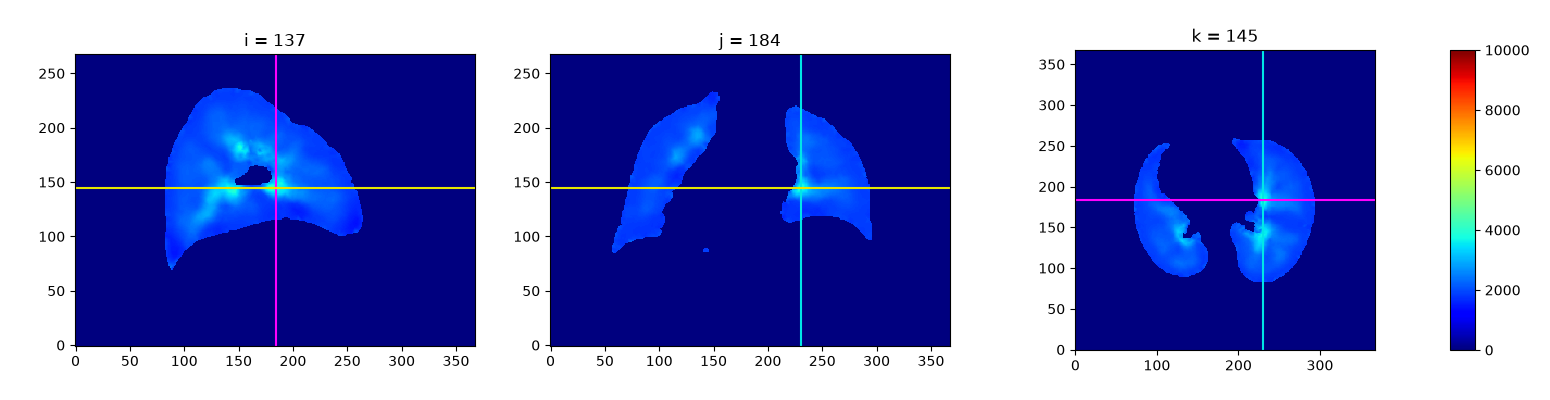

In [53]:
index = (137,184,145)
mpl_viz.SliceViewer(E_pred, index=index, vox_spacing=img0_spacing, ax_height=3, ax_width=4, line_color='cmy', **E_kws)

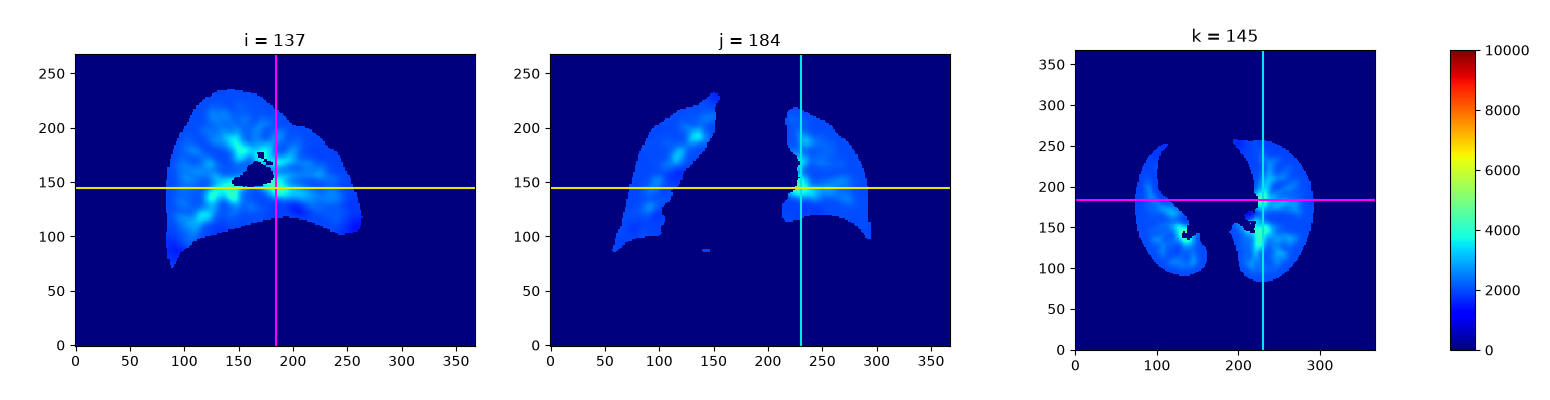

In [54]:
mpl_viz.SliceViewer(E_true, index=index, vox_spacing=img0_spacing, ax_height=3, ax_width=4, line_color='cmy', **E_kws)

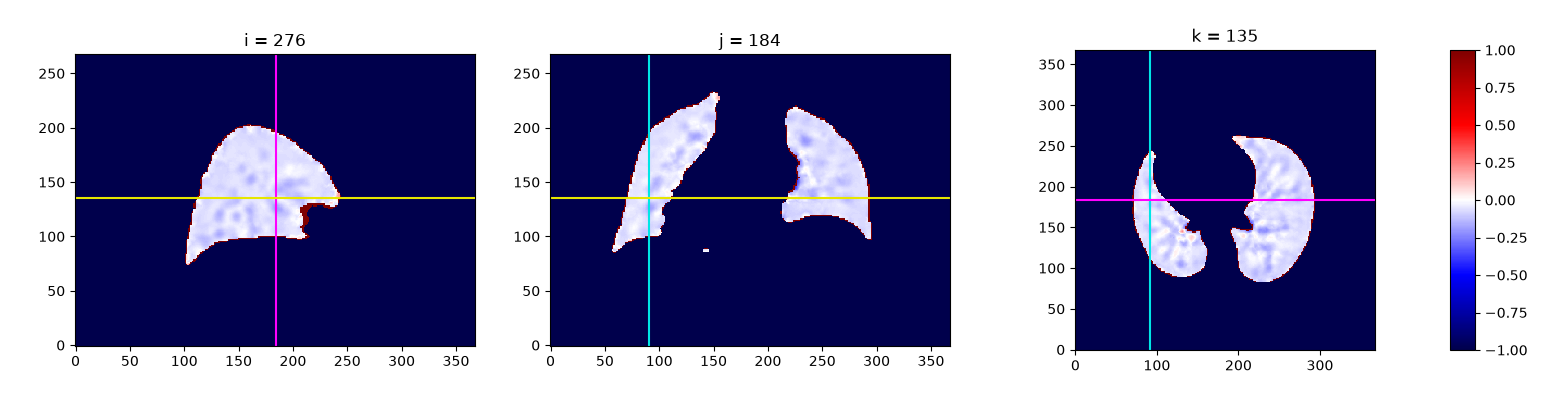

In [57]:
mpl_viz.SliceViewer(
    (E_pred - E_true) / E_true,
    index=(276, 184, 135),
    vox_spacing=img0_spacing,
    ax_height=3, ax_width=4,
    cmap='seismic',
    clim=(-1.0, 1.0),
    line_color='cmy'
)

In [53]:
def compute_error(y_pred, y_true, mask, eps=1e-8):
    return (((y_pred - y_true) / y_true)**2 * mask).mean()

compute_error(E_opt, E.get_fdata(), m)

np.float64(0.0017001486669169343)

In [204]:
rows = []
for i, tv_reg_weight in enumerate(tv_reg_weights):
    outputs = project.core.paths.RunOutputs(stage=f'opt_tv_reg_{i}')
    opt_mesh = project.core.fileio.load_meshio(outputs.mesh_path(ex, name='optimized'))

    u_true = opt_mesh.point_data['u_true']
    u_pred = opt_mesh.point_data['u_pred']

    u_rmse = project.core.metrics.absolute_rmse(u_pred, u_true)
    u_nrmse = project.core.metrics.normalized_rmse(u_pred, u_true)

    E_true, nu_true = project.core.transforms.E_nu_from_mu_lam(
        opt_mesh.point_data['mu_true'], opt_mesh.point_data['lam_true']
    )
    E_pred, nu_pred = project.core.transforms.E_nu_from_mu_lam(
        opt_mesh.point_data['mu_pred'], opt_mesh.point_data['lam_pred']
    )
    E_rmse = project.core.metrics.absolute_rmse(E_pred[:,None], E_true[:,None])
    E_nrmse = project.core.metrics.normalized_rmse(E_pred[:,None], E_true[:,None])

    rows.append([tv_reg_weight, u_rmse, u_nrmse, E_rmse, E_nrmse])

df = pd.DataFrame(rows, columns=['tv_reg_weight', 'u_rmse', 'u_nrmse', 'E_rmse', 'E_nrmse'])
df

Loading outputs/opt_tv_reg_0/16514P/meshes/optimized.xdmf
Loading outputs/opt_tv_reg_1/16514P/meshes/optimized.xdmf
Loading outputs/opt_tv_reg_2/16514P/meshes/optimized.xdmf
Loading outputs/opt_tv_reg_3/16514P/meshes/optimized.xdmf
Loading outputs/opt_tv_reg_4/16514P/meshes/optimized.xdmf
Loading outputs/opt_tv_reg_5/16514P/meshes/optimized.xdmf


,tv_reg_weight,u_rmse,u_nrmse,E_rmse,E_nrmse
0,0.000000e+00,0.000086,0.005800,625.778773,0.262236
1,1.000000e-07,0.000074,0.005042,626.547947,0.262558
2,1.000000e-06,0.000085,0.005794,624.140063,0.261549
3,1.000000e-05,0.000084,0.005700,610.194613,0.255705
4,1.000000e-04,0.000062,0.004185,565.399615,0.236933
5,1.000000e-03,0.000122,0.008307,754.448103,0.316155


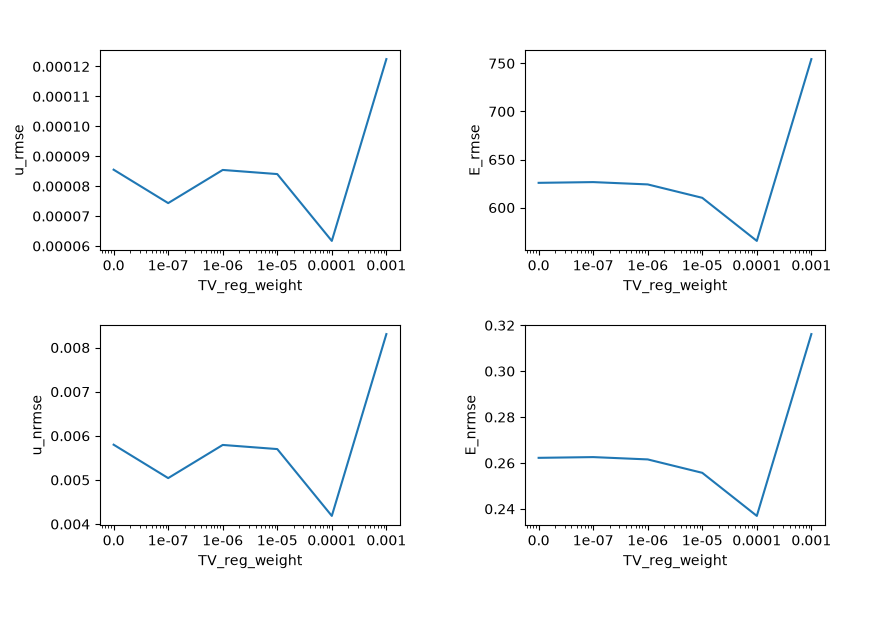

In [205]:
fig, axes = mpl_viz.subplot_grid(2, 2, ax_height=2, ax_width=3, padding=[1.0, 0.5, 1.0, 0.5], spacing=[0.75, 1.25])
axes = axes.flatten()

for i, y_col in enumerate(['u_rmse', 'E_rmse', 'u_nrmse', 'E_nrmse']):
    x_real = list(df.tv_reg_weight)
    x_dummy = [x if x > 0 else 1e-8 for x in x_real]
    axes[i].plot(x_dummy, df[y_col])
    axes[i].set_xlabel('TV_reg_weight')
    axes[i].set_ylabel(y_col)
    #axes[i].set_yscale('log')
    axes[i].set_xscale('log')
    axes[i].set_xticks(x_dummy)
    axes[i].set_xticklabels(x_real)


In [206]:
outputs = project.core.paths.RunOutputs(stage=f'opt_tv_reg_4')
opt_mesh = project.core.fileio.load_meshio(outputs.mesh_path(ex, name='optimized'))
opt_mesh

Loading outputs/opt_tv_reg_4/16514P/meshes/optimized.xdmf


<meshio mesh object>
  Number of points: 36213
  Number of cells:
    tetra: 179256
  Point data: medit:ref, image, u_reg, E, nu, rho, u_fwd, mu_true, mu_pred, lam_true, lam_pred, rho_true, rho_pred, u_true, u_pred, residual
  Cell data: medit:ref, region, image, u_reg, E, nu, rho, u_fwd, mu_true, mu_pred, lam_true, lam_pred, rho_true, rho_pred, u_true, u_pred, residual

In [201]:
def error_vs_boundary(mesh, bins):
    import numpy as np
    import pandas as pd
    import scipy.spatial

    cells = mesh.cells_dict['tetra']
    faces = np.vstack([
        cells[:, [0, 1, 2]],
        cells[:, [0, 1, 3]],
        cells[:, [0, 2, 3]],
        cells[:, [1, 2, 3]],
    ])
    faces = np.sort(faces, axis=1)
    faces, counts = np.unique(faces, axis=0, return_counts=True)
    boundary_nodes = np.unique(faces[counts == 1])

    tree = scipy.spatial.cKDTree(mesh.points[boundary_nodes])
    distance = tree.query(mesh.points)[0]

    def _E(mu, lam):
        return mu * (3 * lam + 2 * mu) / (lam + mu)

    E_true = _E(mesh.point_data['mu_true'], mesh.point_data['lam_true'])
    E_pred = _E(mesh.point_data['mu_pred'], mesh.point_data['lam_pred'])
    relative_error = (E_pred - E_true) / E_true

    df = pd.DataFrame({
        'distance': distance,
        'E_true': E_true,
        'E_pred': E_pred,
        'relative_error': relative_error,
        'abs_relative_error': np.abs(relative_error),
    })
    df['distance_bin'] = pd.cut(distance, bins=bins, include_lowest=True)

    summary = (
        df.groupby('distance_bin', observed=True)
        .agg(
            n=('relative_error', 'size'),
            mean_error=('relative_error', 'mean'),
            mean_abs_error=('abs_relative_error', 'mean'),
            median_error=('relative_error', 'median')
        ).reset_index()
    )
    return df, summary

df, summary = error_vs_boundary(opt_mesh, bins=[0, 2, 5, 10, 20, float('inf')])
summary

,distance_bin,n,mean_error,mean_abs_error,median_error
0,"(-0.001, 2.0]",12465,0.789906,0.795013,0.714204
1,"(2.0, 5.0]",6053,-0.045286,0.089453,-0.039381
2,"(5.0, 10.0]",6887,0.165253,0.174482,0.165582
3,"(10.0, 20.0]",8723,0.169789,0.169803,0.173273
4,"(20.0, inf]",2085,0.182552,0.182552,0.181835


Text(0, 0.5, 'Relative error')

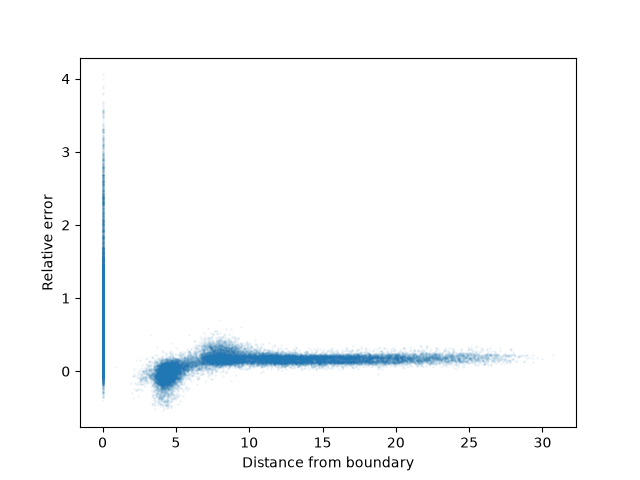

In [202]:
fig, ax = plt.subplots()
ax.scatter(df['distance'], df['relative_error'], s=1, alpha=0.05)
ax.set_xlabel('Distance from boundary')
ax.set_ylabel('Relative error')

In [96]:
def test_loss_path(ex, config, alphas):
    from project import core, datasets, physics, optimization
    import torch

    sample = datasets.api.load_example(ex)
    mesh = sample['mesh']
    unit_m = float(ex.metadata['unit'])

    adapter = physics.api.get_adapter(config)
    bc_spec = physics.api.get_bc_spec(config)

    param_specs = optimization.build_parameter_specs(config)
    init_spec = optimization.build_initialize_spec(config)

    ctx = adapter.get_physics_context(mesh, unit_m)
    E_true = ctx.fields['E'][adapter.scalar_degree]
    z_true = param_specs['E'].encode(E_true)

    param_dofs = optimization.initialize_param_dofs(
        adapter, mesh, unit_m, param_specs, init_spec
    )
    with torch.no_grad():
        z_init = param_dofs['E']

        losses = []
        for alpha in alphas:
            z = (1 - alpha) * z_init + alpha * z_true
            E = param_specs['E'].decode(z)
        
            loss = adapter.mesh_simulation_loss(
                mesh, unit_m, params={'E': E}, bc_spec=bc_spec, ret_outputs=False
            )
            losses.append(loss.item())

    return losses

alphas = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999, 1.0]
losses = test_loss_path(ex, opt_config, alphas)
list(zip(alphas, losses))

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v1_v2_int_linear.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v2_label.nii.gz
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A6000" (44 GiB, sm_86, mempool enabled)
   Kernel cache:
     /usr2/collab/mragoza/.cache/warp/1.15.0
Targets: ['E']
Module warp.fem.utils 21e5a09 load on device 'cuda:0' took 256.56 ms  (cached)
Module warp.fem.geometry.tetmesh 681bff0 load on device 'cuda:0' took 43.02 ms  (cached)
Module warp.fem.geometry.tetmesh 9b319f1 load on device 'cuda:0' took 50.77 ms  (

[(0.0, 0.014792748726904392),
 (0.1, 0.011779050342738628),
 (0.25, 0.007917223498225212),
 (0.5, 0.0032742563635110855),
 (0.75, 0.0007479636115022004),
 (0.9, 0.00011441935203038156),
 (0.99, 3.7292979868652765e-06),
 (0.999, 2.6878817607212113e-06),
 (1.0, 2.6798134058481082e-06)]

Text(0, 0.5, 'loss')

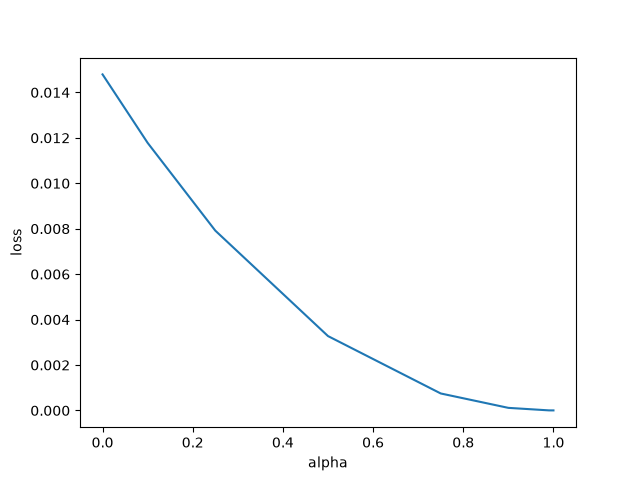

In [97]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(alphas, losses)
ax.set_xlabel('alpha')
ax.set_ylabel('loss')

In [101]:
def test_gradient(ex, config):
    from project import datasets, physics, optimization
    import torch

    sample = datasets.api.load_example(ex)
    mesh = sample['mesh']
    unit_m = float(ex.metadata['unit'])

    adapter = physics.api.get_adapter(config)
    bc_spec = physics.api.get_bc_spec(config)

    param_specs = optimization.build_parameter_specs(config)
    init_spec = optimization.build_initialize_spec(config)

    ctx = adapter.get_physics_context(mesh, unit_m)
    E_true = ctx.fields['E'][adapter.scalar_degree]
    z_true = param_specs['E'].encode(E_true)

    param_dofs = optimization.initialize_param_dofs(
        adapter, mesh, unit_m, param_specs, init_spec
    )
    z_init = param_dofs['E']
    E_init = param_specs['E'].decode(z_init)

    loss = adapter.mesh_simulation_loss(
        mesh, unit_m, params={'E': E_init}, bc_spec=bc_spec, ret_outputs=False
    )
    print(f'loss: {loss.item()}')

    loss.backward()
    grad = z_init.grad.detach()
    diff = z_true - z_init.detach()

    print(f'gradient norm: {torch.linalg.vector_norm(grad).item()}')
    print(f'true dir norm: {torch.linalg.vector_norm(diff).item()}')

    dot = torch.sum(grad * diff)
    cos = dot / (
        torch.linalg.vector_norm(grad) * torch.linalg.vector_norm(diff)
    )
    print(f'dot product: {dot.item()}')
    print(f'cosine: {cos.item()}')

    z_init = z_init.detach()

    def loss_at_alpha(alpha):
        with torch.no_grad():
            z = z_init + alpha * diff
            E = param_specs['E'].decode(z)
            loss = adapter.mesh_simulation_loss(
                mesh, unit_m, params={'E': E}, bc_spec=bc_spec, ret_outputs=False
            )
        return loss.item()

    for eps in [1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4]:
        loss_pos = loss_at_alpha(+eps)
        loss_neg = loss_at_alpha(-eps)
        fd_grad = (loss_pos - loss_neg) / (2 * eps)
        print(f'eps = {eps}  fd_grad = {fd_grad:.8f}  autograd = {dot.item():.8f}  ratio = {fd_grad / dot.item():.8f}')

    direction = -grad / torch.linalg.vector_norm(grad)
    
    def loss_at_step(step):
        with torch.no_grad():
            z = z_init + step * direction
            E = param_specs['E'].decode(z)
            loss = adapter.mesh_simulation_loss(
                mesh, unit_m, params={'E': E}, bc_spec=bc_spec, ret_outputs=False
            )
        return loss.item()

    for step in [0, 0.01, 0.03, 0.1, 0.3, 1.0, 3., 10., 30., 100.]:
        loss = loss_at_step(step)
        print(f'step = {step}  loss = {loss:.4f}')

test_gradient(ex, opt_config)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v1_v2_int_linear.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v2_label.nii.gz
Targets: ['E']
loss: 0.014792748726904392
gradient norm: 0.0008181812590919435
true dir norm: 61.609500885009766
dot product: -0.03183695301413536
cosine: -0.6315886378288269
eps = 0.1  fd_grad = -0.03180214  autograd = -0.03183695  ratio = 0.99890644
eps = 0.03  fd_grad = -0.03183819  autograd = -0.03183695  ratio = 1.00003896
eps = 0.01  fd_grad = -0.03185119  autograd = -0.03183695  ratio = 1.00044704
eps = 0.003  fd_grad = -0.03183276  autograd = -0.03183695  ratio = 0.99986832
eps = 0

# High-quality visualizations

In [30]:
ex = project.api.get_examples(data_config_v2)[0]

img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
anat = project.core.fileio.load_nibabel(ex.paths['anatomical_map'])
m = anat.get_fdata() > 0

emph = project.core.fileio.load_nibabel(ex.paths['init_state']['segment_dir'] / 'lt-950.nii.gz')

E = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

#E_pred = project.core.fileio.load_nibabel(outputs.raster_dir(ex_v0) / 'E_pred.nii.gz')

mesh = project.core.fileio.load_meshio(ex.paths['forward_mesh'])

Gathering examples
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0/lt-950.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v2/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v2/poisson_ratio.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v2/density.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP

In [42]:
import matplotlib.pyplot as plt
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)
z = 120
c = 48

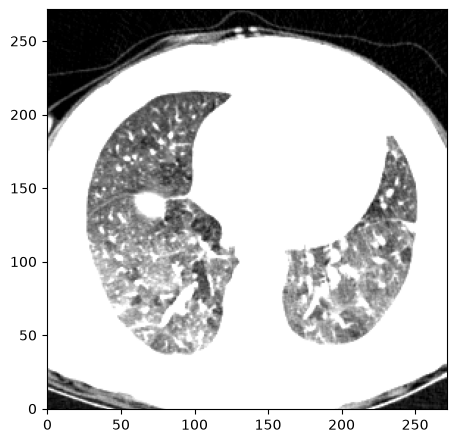

In [34]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img0.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

fig

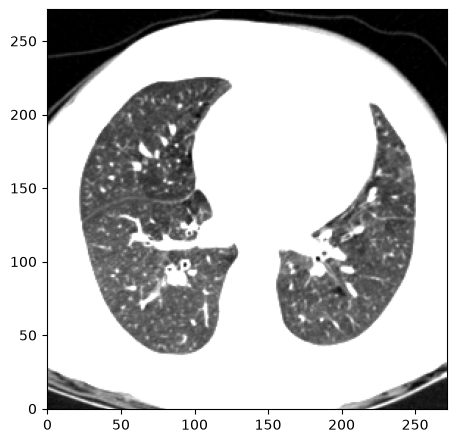

In [35]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img1.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)
fig

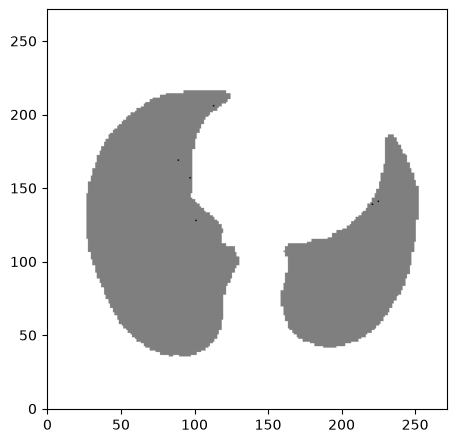

In [36]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(((emph.get_fdata() + 1)*m)[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 2))
fig

In [37]:
m = anat.get_fdata() > 0
E_m = E.get_fdata() * m
nu_m = nu.get_fdata() * m
rho_m = rho.get_fdata() * m

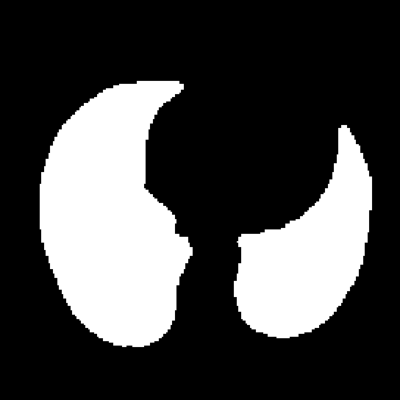

In [43]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(m[c:-c,c:-c,z].T, origin='lower', cmap='gray')

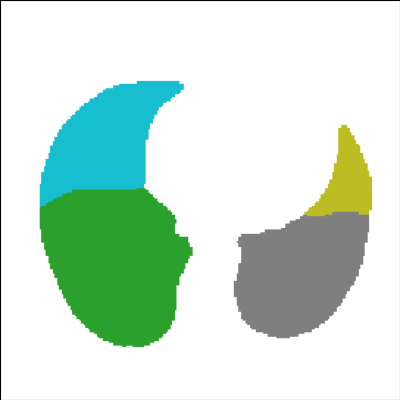

In [44]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow((anat.get_fdata())[c:-c,c:-c,z].T, origin='lower', cmap=mpl_viz.get_label_cmap(5, include_bg=True))

In [56]:
E_m.shape

(368, 368, 268)

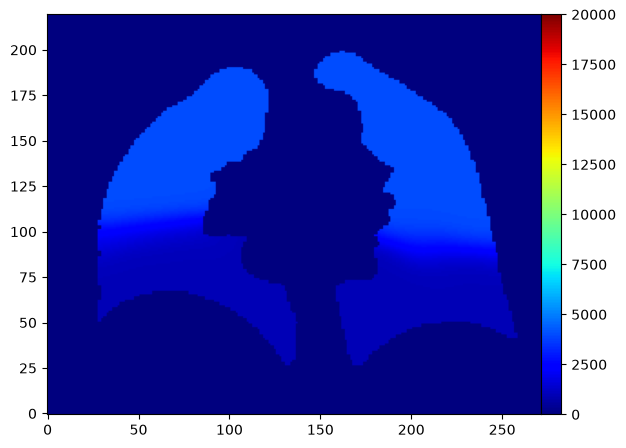

In [89]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4.95, cbar_width=0.2, padding=0.6)

im = ax[0,0].imshow(E_m[c:-c,160,c:].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)
fig

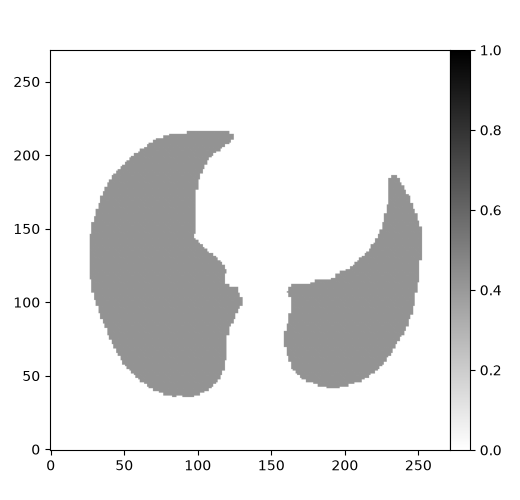

In [132]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(nu_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1))
plt.colorbar(im, cax)

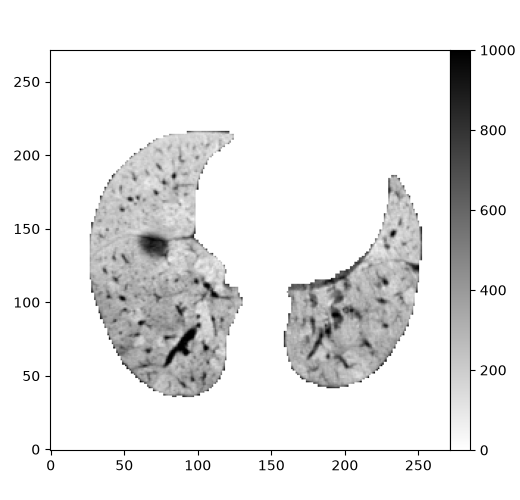

In [133]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(rho_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1000))
plt.colorbar(im, cax)

In [138]:
np.mean(E_v0_m - E_v1_m)

np.float64(-0.020107227646429714)

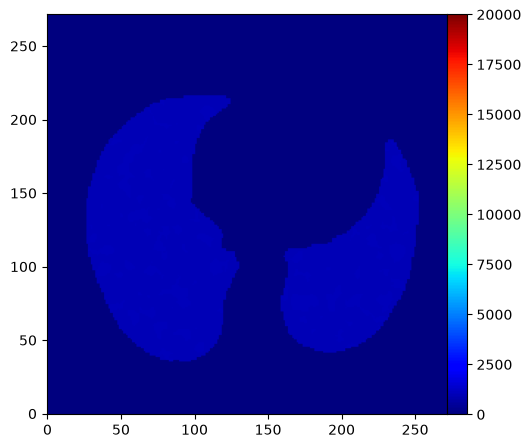

In [136]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(E_v0_m[c:-c,c:-c,z].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)
fig

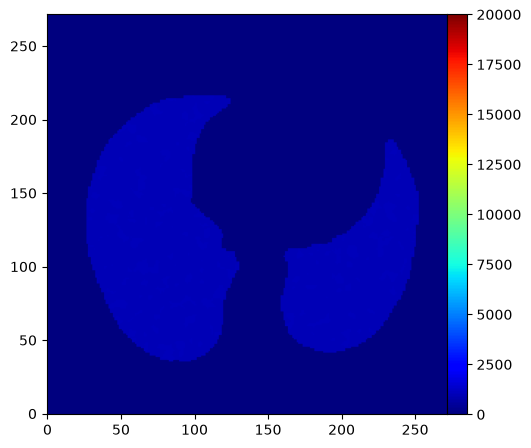

In [137]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(E_v1_m[c:-c,c:-c,z].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)
fig

In [41]:
np.unique(mesh.cell_data['region'])

array([1, 2, 3, 4, 5])

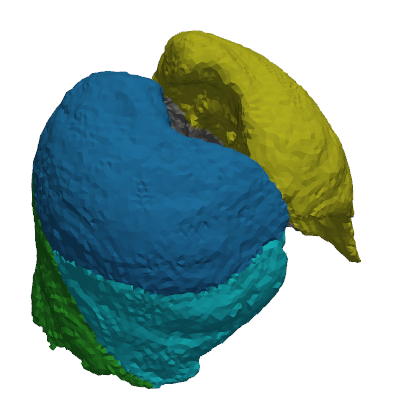

In [137]:
def show_mesh(mesh):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, scalars='region', show_scalar_bar=False, clim=(1, 5), opacity=1.0, cmap=mpl_viz.get_label_cmap(5, include_bg=False))
    #g = m.glyph(scale=key, orient=key, factor=1.0)
    #p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.4)
    p.show(jupyter_backend='static')

show_mesh(mesh)

In [158]:
vmax = np.percentile(np.linalg.norm(mesh.point_data['u_reg'], axis=1), 99)
vmax

np.float32(28.082287)

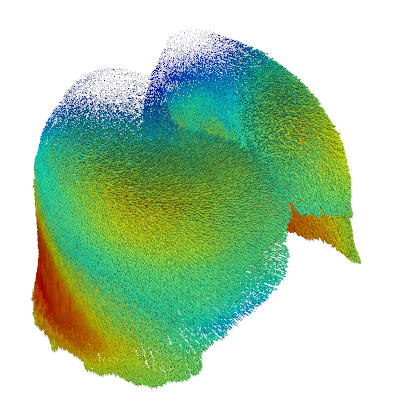

In [192]:
def plot_disp(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    #p.add_mesh(m, scalars=key, show_scalar_bar=False)
    g = m.glyph(scale=key, orient=key, factor=0.5)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet', clim=(0, vmax))
    p.camera.zoom(1.4)
    return p

p = plot_disp(mesh, key='u_reg')
p.show(jupyter_backend='static')

In [193]:
import pyvista as pv
surf = pv.wrap(mesh).extract_surface(algorithm='geometry')

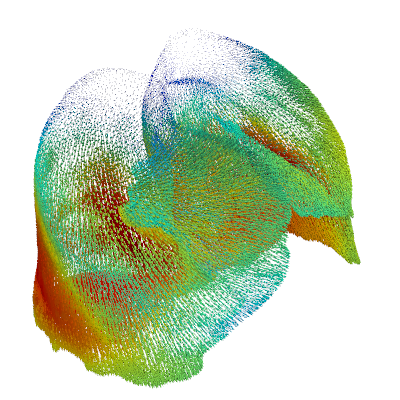

In [194]:
p = plot_disp(surf, key='u_reg')
p.show(jupyter_backend='static')

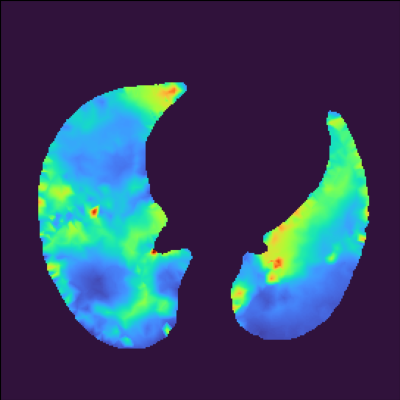

In [130]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(K_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 20000))

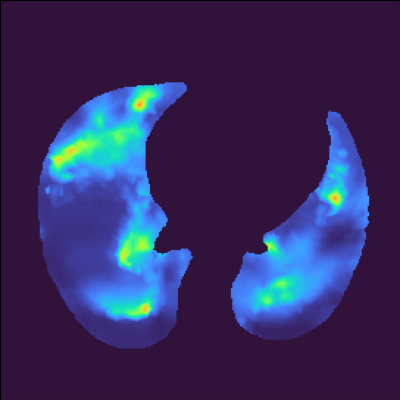

In [132]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(G_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 10000))

In [133]:
mesh = project.core.fileio.load_meshio('outputs/opt_linear/16514P/meshes/optimized.xdmf')
mesh

Loading outputs/opt_linear/16514P/meshes/optimized.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual
  Cell data: medit:ref, region, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual

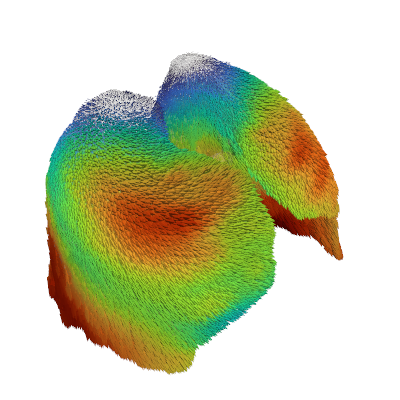

In [161]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.25)
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

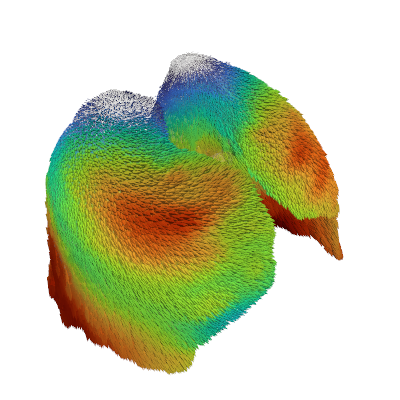

In [162]:
show_mesh(mesh, key='u_pred')

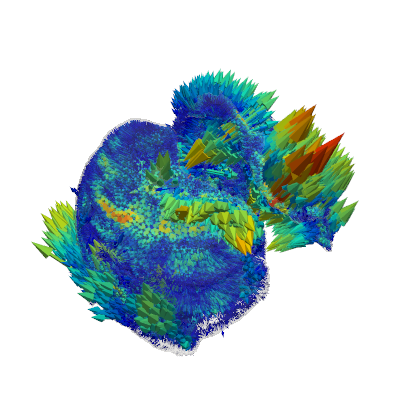

In [142]:
show_mesh(mesh, key='residual')